In [2]:
from OrthoSAM import orthosam
from OrthoSAM.utility import setup, load_config, accuracy, graph_coloring
import os
from tifffile import imread, imwrite, TiffFile
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def precision_recall(AcDic):
    #threshold=0.9
    #iou = np.abs(np.array(AcDic.get('iou')))
    ac_class, count = np.unique(AcDic.get('point based'), return_counts=True)
    #TP_count = np.sum(iou >= threshold)
    TP_count = np.sum(count[ac_class > 0]) if 1 in ac_class else 0
    Label_count = AcDic.get('label_count')
    MSK_T = AcDic.get('mask_count')

    precision = TP_count / MSK_T
    recall = TP_count / Label_count
    print('Precision: ', precision)
    print('Recall: ', recall)
    #return precision, recall
from scipy.stats import ks_2samp
def ks_Dict(AcDic):
    sizes = np.sort(AcDic.get('area'))
    sizes_re = np.sort(AcDic.get('segment area'))
    ks=ks_2samp(sizes_re,sizes, method= 'exact', alternative='two-sided')
    return ks

In [4]:
mask_FH=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/FH_pred.tif')
#pred_FH=np.load('/DATA/vito/output/ImageGrains_0_up2_org_b300/Merged/all_mask_merged_windows_id_001.npy')
pred_FH=np.load('/DATA/vito/output/ImageGrain_FH.jpg/Merged/Merged_Layers_001.npy')
pred2_FH=np.load('/DATA/vito/output/ImageGrain_FH_large/Merged/Merged_Layers_001.npy')
mask_K1=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/K1_pred.tif')
#pred_K1=np.load('/DATA/vito/output/ImageGrains_4_up2_org_b300/Merged/all_mask_merged_windows_id_001.npy')
pred_K1=np.load('/DATA/vito/output/ImageGrain_K1.jpg/Merged/Merged_Layers_001.npy')
pred2_k1=np.load('/DATA/vito/output/ImageGrain_K1_large/Merged/Merged_Layers_001.npy')
mask_S1=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/S1_pred.tif')
pred_S1=np.load('/DATA/vito/output/ImageGrain_S1.jpg/Merged/Merged_Layers_001.npy')
pred2_S1=np.load('/DATA/vito/output/ImageGrain_S1_large/Merged/Merged_Layers_001.npy')
#pred_S1=np.load('/DATA/vito/output/ImageGrains_7_up2_org_b300/Merged/all_mask_merged_windows_id_001.npy')

In [5]:
import cv2
pred_FH=cv2.resize(pred_FH, (mask_FH.shape[1], mask_FH.shape[0]), interpolation=cv2.INTER_NEAREST)
pred_K1=cv2.resize(pred_K1, (mask_K1.shape[1], mask_K1.shape[0]), interpolation=cv2.INTER_NEAREST)
pred_S1=cv2.resize(pred_S1, (mask_S1.shape[1], mask_S1.shape[0]), interpolation=cv2.INTER_NEAREST)
pred2_FH=cv2.resize(pred2_FH, (mask_FH.shape[1], mask_FH.shape[0]), interpolation=cv2.INTER_NEAREST)
pred2_k1=cv2.resize(pred2_k1, (mask_K1.shape[1], mask_K1.shape[0]), interpolation=cv2.INTER_NEAREST)
pred2_S1=cv2.resize(pred2_S1, (mask_S1.shape[1], mask_S1.shape[0]), interpolation=cv2.INTER_NEAREST)

In [8]:
AcDic_FH=accuracy(mask_FH, pred_FH)
precision_recall(AcDic_FH)
#ks_Dict(AcDic_FH)
AcDic_K1=accuracy(mask_K1, pred_K1)
precision_recall(AcDic_K1)
#ks_Dict(AcDic_K1)
AcDic_S1=accuracy(mask_S1, pred_S1)
precision_recall(AcDic_S1)
#ks_Dict(AcDic_S1)

1742  mask(s) loaded
No. of ground truth objects: 2819
Mean mask IoU: 
0.41972147051379793
Precision:  0.8559127439724454
Recall:  0.5289109613338063
1883  mask(s) loaded
No. of ground truth objects: 1358
Mean mask IoU: 
0.7707705903802051
Precision:  0.648964418481147
Recall:  0.8998527245949927
4660  mask(s) loaded
No. of ground truth objects: 4316


KeyboardInterrupt: 

In [7]:
AcDic_FH=accuracy(pred_FH, mask_FH)
precision_recall(AcDic_FH)
ks_Dict(AcDic_FH)
AcDic_K1=accuracy(pred_K1, mask_K1)
precision_recall(AcDic_K1)
ks_Dict(AcDic_K1)
AcDic_S1=accuracy(pred_S1, mask_S1)
precision_recall(AcDic_S1)
ks_Dict(AcDic_S1)

2819  mask(s) loaded
No. of ground truth objects: 1742
Mean mask IoU: 
0.6614998881040736
Precision:  0.501423487544484
Recall:  0.8088404133180253
1358  mask(s) loaded
No. of ground truth objects: 1883
Mean mask IoU: 
0.5562950900558354
Precision:  0.9005891016200295
Recall:  0.6494954859267127
4316  mask(s) loaded
No. of ground truth objects: 4660
Mean mask IoU: 
0.5997196605428675
Precision:  0.7818223974031996
Recall:  0.7236051502145923


KstestResult(statistic=np.float64(0.1511076901950287), pvalue=np.float64(4.482367571533744e-45), statistic_location=np.int64(165), statistic_sign=np.int8(-1))

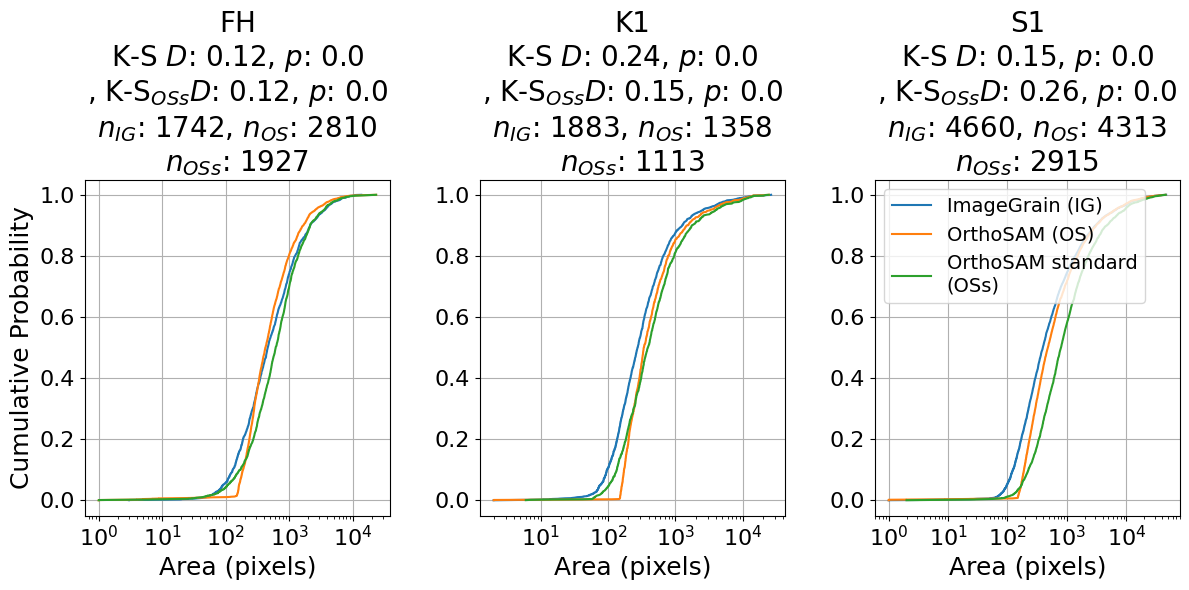

In [6]:
def cdf(title_label, mask, pred_mask, pred2_mask):    
    sizes = np.sort(np.unique(mask, return_counts=True)[1][1:])
    cdf = np.arange(1, len(sizes) + 1) / len(sizes)
    plt.plot(sizes, cdf, linestyle="-", label='ImageGrain (IG)')
    plt.title(title_label, fontsize=20)
    
    sizes_re = np.sort(np.unique(pred_mask, return_counts=True)[1][1:])
    cdf_re = np.arange(1, len(sizes_re) + 1) / len(sizes_re)
    plt.plot(sizes_re, cdf_re, linestyle="-", label='OrthoSAM (OS)')
    ks_test=ks_2samp(sizes_re,sizes, method= 'exact', alternative='two-sided')
    # ac_class, count = np.unique(AcDic.get('point based'), return_counts=True)
    # TP_count = np.sum(count[ac_class > 0]) if 1 in ac_class else 0
    # Label_count = AcDic.get('label_count')
    # MSK_T = AcDic.get('mask_count')

    sizes_re2 = np.sort(np.unique(pred2_mask, return_counts=True)[1][1:])
    cdf_2= np.arange(1, len(sizes_re2) + 1) / len(sizes_re2)
    plt.plot(sizes_re2, cdf_2, linestyle="-", label='OrthoSAM standard\n(OSs)')
    ks_test2=ks_2samp(sizes_re2,sizes, method= 'exact', alternative='two-sided')


    #precision = TP_count / MSK_T
    #recall = TP_count / Label_count
    plt.title(title_label+'\n'
              +fr'K-S $D$: {np.round(ks_test[0],2):.2}, $p$: {np.round(ks_test[1],2):.3}'
              +'\n'+r', K-S$_{OSs}$'+ f'$D$: {np.round(ks_test2[0],2):.2}, $p$: {np.round(ks_test2[1],2):.3}'
              +'\n'+r'$n_{IG}$'
              +f': {len(sizes)}, '
              +r'$n_{OS}$'+f': {len(sizes_re)}'
              +'\n'+r'$n_{OSs}$'+f': {len(sizes_re2)}'
              #+'\n'+f'P: {precision:.2}, R: {recall:.2}'
              , fontsize=20)

    plt.xscale("log")
    plt.xlabel("Area (pixels)", fontsize=18)
    plt.ylabel("Cumulative Probability", fontsize=18) 
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)       
    plt.grid(True)
plt.figure(figsize=(12, 6))
plt.subplot(1,3,1)
cdf('FH', mask_FH, pred_FH, pred2_FH)
plt.subplot(1,3,2)
cdf('K1', mask_K1, pred_K1, pred2_k1)
plt.ylabel('')
plt.subplot(1,3,3)
cdf('S1', mask_S1, pred_S1, pred2_S1)
plt.legend(fontsize=14)
plt.tight_layout()
plt.xlabel('Area (pixels)')
plt.ylabel('')
plt.savefig('/DATA/vito/fig/shadowed_dist.png')

In [6]:
mask_FH=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/FH_pred.tif')
import cv2
import numpy as np
img = cv2.imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/FH.jpg')
img_FH = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/S1.jpg')
img_S1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/K1.jpg')
img_K1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [48]:
def transfer_colors(mask_a_orig, mask_b_orig, mask_a_colored, mask_b_colored):
    mask_b_updated = mask_b_colored.copy()
    
    labels_a, size = np.unique(mask_a_orig, return_counts=True)
    labels_a = labels_a[labels_a != 0]
    labels_a = labels_a[np.argsort(size[1:])]
    
    labels_b = np.unique(mask_b_orig)
    labels_b = labels_b[labels_b != 0]

    for la in labels_a:
        a_pixels = (mask_a_orig == la)
        
        overlapping_b = mask_b_orig[a_pixels]
        vals, counts = np.unique(overlapping_b, return_counts=True)
        
        mask_nonzero = (vals != 0)
        vals = vals[mask_nonzero]
        counts = counts[mask_nonzero]
        
        if len(vals) == 0:
            continue
        
        best_b = vals[np.argmax(counts)]
        mask_b_updated[mask_b_orig == best_b] = mask_a_colored[a_pixels][0]
        
    return mask_b_updated

In [7]:
labels, count=np.unique(pred_FH, return_counts=True)
labels=labels[count<0]
pred_FH_f=pred_FH.copy()
for l in labels:
    pred_FH_f[pred_FH_f==l]=0

/tmp/ipykernel_1557215/626386596.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels([int(1025+x*250/5) for x in range(6)])
/tmp/ipykernel_1557215/626386596.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_yticklabels([int(y + y0) for y in yticks])
/tmp/ipykernel_1557215/626386596.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,2].set_xticklabels([int(1025+x*250/5) for x in range(6)])
/tmp/ipykernel_1557215/626386596.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,2].set_yticklabels([int(y + y0) for y in yticks])
/tmp/ipykernel_1557215/626386596.py:39: UserWarning: set_ticklabels() should only be

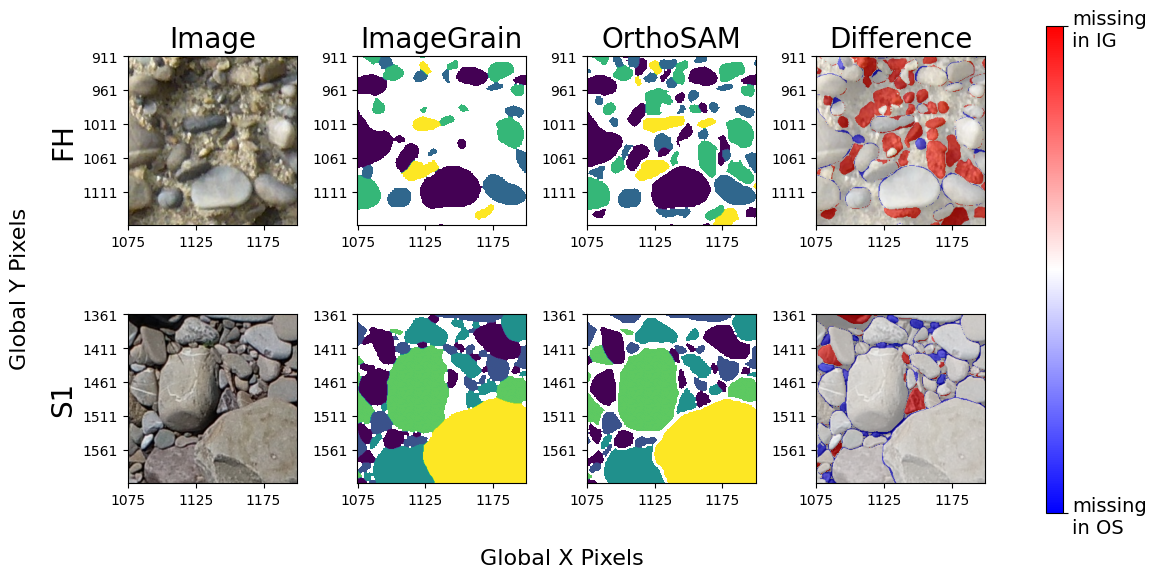

In [51]:
# plt.figure(figsize=(12, 8))
# plt.subplot(2,4,1)
from matplotlib.gridspec import GridSpec
fig, ax = plt.subplots(2, 4, figsize=(12, 6))

gs = GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 1, 1, 0.1])
for i in range(2):
    for j in range(4):
        ax[i, j].set_subplotspec(gs[i, j])
ax[0,0].imshow(img_FH[img_FH.shape[0]//2:img_FH.shape[0]//2+250,img_FH.shape[1]//2:img_FH.shape[1]//2+250,:])
ax[0,0].set_title('Image', fontsize=20)
ax[0,0].set_ylabel('FH', fontsize=20)
#ax[0,0].set_ylabel('Global pixels')
x0, y0 = img_FH.shape[0]//2, img_FH.shape[1]//2
xticks = ax[0,0].get_xticks()
yticks = ax[0,0].get_yticks()
ax[0,0].set_xticklabels([int(1025+x*250/5) for x in range(6)])
ax[0,0].set_yticklabels([int(y + y0) for y in yticks])

#plt.subplot(2,4,3)
pred_FH_p = pred_FH_f.copy().astype("float")
pred_FH_p[pred_FH_p == 0] = np.nan
pred_FH_p = graph_coloring(pred_FH_p)
ax[0,2].imshow(pred_FH_p[pred_FH_p.shape[0]//2:pred_FH_p.shape[0]//2+250,pred_FH_p.shape[1]//2:pred_FH_p.shape[1]//2+250])
ax[0,2].set_title('OrthoSAM', fontsize=20)
#ax[0,2].set_xticks(xticks)
ax[0,2].set_xticklabels([int(1025+x*250/5) for x in range(6)])
#ax[0,2].set_yticks(yticks)
ax[0,2].set_yticklabels([int(y + y0) for y in yticks])

#plt.subplot(2,4,2)
mask_FH_p = mask_FH.copy().astype("float")
mask_FH_p[mask_FH_p == 0] = np.nan
mask_FH_p = graph_coloring(mask_FH_p)
mask_FH_p = transfer_colors(pred_FH_f, mask_FH, pred_FH_p, mask_FH_p)
ax[0,1].imshow(mask_FH_p[mask_FH_p.shape[0]//2:mask_FH_p.shape[0]//2+250,mask_FH_p.shape[1]//2:mask_FH_p.shape[1]//2+250])
ax[0,1].set_title('ImageGrain', fontsize=20)
#ax[0,1].set_xticks(xticks)
ax[0,1].set_xticklabels([int(1025+x*250/5) for x in range(6)])
#ax[0,1].set_yticks(yticks)
ax[0,1].set_yticklabels([int(y + y0) for y in yticks])

#plt.subplot(2,4,4)
pred_FH_b=pred_FH_f>0
mask_FH_b=mask_FH>0
diff=pred_FH_b.astype(int) - mask_FH_b.astype(int)
diff=diff[diff.shape[0]//2:diff.shape[0]//2+250,diff.shape[1]//2:diff.shape[1]//2+250]

im = ax[0,3].imshow(np.where(diff == 0, np.nan, diff.astype(float)), cmap="bwr")
# cb = plt.colorbar(im, ax=ax[0,3], location="right", fraction=0.05, pad=0.05)
# cb.set_ticks(ticks=[-1, 1], labels=["missing\nin OS", "missing\nin IG"])
ax[0,3].imshow(diff, cmap='bwr', vmin=-np.nanmax(np.abs(diff)), vmax=np.nanmax(np.abs(diff)))
ax[0,3].imshow(img_FH[img_FH.shape[0]//2:img_FH.shape[0]//2+250,img_FH.shape[1]//2:img_FH.shape[1]//2+250,:], alpha=0.5)
ax[0,3].set_title('Difference', fontsize=20)
ax[0,3].set_xticklabels([int(1025+x*250/5) for x in range(6)])
ax[0,3].set_yticklabels([int(y + y0) for y in yticks])
#plt.subplot(2,4,5)


ax[1,0].imshow(img_S1[img_S1.shape[0]//2:img_S1.shape[0]//2+250,img_S1.shape[1]//2:img_S1.shape[1]//2+250,:])
ax[1,0].set_ylabel('S1', fontsize=20)
#ax[1,0].set_ylabel('Global pixels')
x0, y0 = img_S1.shape[0]//2, img_S1.shape[1]//2
xticks = ax[1,0].get_xticks()
yticks = ax[1,0].get_yticks()
ax[1,0].set_xticklabels([int(1025+x*250/5) for x in range(6)])
ax[1,0].set_yticklabels([int(y + y0) for y in yticks])

#plt.subplot(2,4,7)
pred_S1_p = pred_S1.copy().astype("float")
pred_S1_p[pred_S1_p == 0] = np.nan
pred_S1_p = graph_coloring(pred_S1_p)
ax[1,2].imshow(pred_S1_p[pred_S1_p.shape[0]//2:pred_S1_p.shape[0]//2+250,pred_S1_p.shape[1]//2:pred_S1_p.shape[1]//2+250])
# ax[1,2].set_title('OrthoSAM', fontsize=20)
#ax[1,2].set_xlabel('Global pixels')
ax[1,2].set_xticklabels([int(1025+x*250/5) for x in range(6)])
ax[1,2].set_yticklabels([int(y + y0) for y in yticks])

mask_S1_p = mask_S1.copy().astype("float")
mask_S1_p[mask_S1_p == 0] = np.nan
mask_S1_p = graph_coloring(mask_S1_p)
mask_S1_p = transfer_colors(pred_S1, mask_S1, pred_S1_p, mask_S1_p)
ax[1,1].imshow(mask_S1_p[mask_S1_p.shape[0]//2:mask_S1_p.shape[0]//2+250,mask_S1_p.shape[1]//2:mask_S1_p.shape[1]//2+250])
# ax[1,1].set_title('ImageGrain', fontsize=20)
#ax[1,1].set_xlabel('Global pixels')
ax[1,1].set_xticklabels([int(1025+x*250/5) for x in range(6)])
ax[1,1].set_yticklabels([int(y + y0) for y in yticks])

#plt.subplot(2,4,8)
pred_S1_b=pred_S1>0
mask_S1_b=mask_S1>0
diff=pred_S1_b.astype(int) - mask_S1_b.astype(int)
diff=diff[diff.shape[0]//2:diff.shape[0]//2+250,diff.shape[1]//2:diff.shape[1]//2+250]
im = ax[1,3].imshow(np.where(diff == 0, np.nan, diff.astype(float)), cmap="bwr")
# cb = plt.colorbar(im, ax=ax[1,3], location="right", fraction=0.05, pad=0.05)
# cb.set_ticks(ticks=[-1, 1], labels=["missing\nin OS", "missing\nin IG"])
ax[1,3].imshow(diff, cmap='bwr', vmin=-np.nanmax(np.abs(diff)), vmax=np.nanmax(np.abs(diff)))
ax[1,3].imshow(img_S1[img_S1.shape[0]//2:img_S1.shape[0]//2+250,img_S1.shape[1]//2:img_S1.shape[1]//2+250,:], alpha=0.5)
# ax[1,3].set_title('Difference', fontsize=20)
#ax[1,3].set_xlabel('Global pixels')
ax[1,3].set_xticklabels([int(1025+x*250/5) for x in range(6)])
ax[1,3].set_yticklabels([int(y + y0) for y in yticks])
fig.text(0.5, 0.04, "Global X Pixels", ha="center", fontsize=16)
fig.text(0.04, 0.5, "Global Y Pixels", va="center", rotation="vertical", fontsize=16)

cax = fig.add_subplot(gs[:, 4])

cb = fig.colorbar(im, cax=cax)
cb.set_ticks([-1, 1])
cb.set_ticklabels(["missing\nin OS", "missing\nin IG"])

for label in cb.ax.get_yticklabels():
    #label.set_rotation(270)
    #label.set_verticalalignment('center')
    label.set_fontsize(14) 

plt.tight_layout(rect=[0.06, 0.06, 1, 1])
#plt.savefig('/DATA/vito/fig/shadowed_example.png')

In [14]:
from OrthoSAM.utility import get_props_df
from skimage.measure import label

props_df_FH=get_props_df(img_FH, pred_FH, 1, 1)
props_df_FH=props_df_FH[props_df_FH['area']>100]
props_df_FH = props_df_FH[np.isfinite(props_df_FH['IRn'])].reset_index(drop=True)
labeled_mask_FH = label(pred_FH, background=0)

props_df_K1=get_props_df(img_K1, pred_K1, 1, 1)
props_df_K1=props_df_K1[props_df_K1['area']>100]
props_df_K1 = props_df_K1[np.isfinite(props_df_K1['IRn'])].reset_index(drop=True)
labeled_mask_K1 = label(pred_K1, background=0)

props_df_S1=get_props_df(img_S1, pred_S1, 1, 1)
props_df_S1=props_df_S1[props_df_S1['area']>100]
props_df_S1 = props_df_S1[np.isfinite(props_df_S1['IRn'])].reset_index(drop=True)
labeled_mask_S1 = label(pred_S1, background=0)


props_df_FH2=get_props_df(img_FH, pred2_FH, 1, 1)
props_df_FH2=props_df_FH2[props_df_FH2['area']>100]
props_df_FH2 = props_df_FH2[np.isfinite(props_df_FH2['IRn'])].reset_index(drop=True)


props_df_K12=get_props_df(img_K1, pred2_k1, 1, 1)
props_df_K12=props_df_K12[props_df_K12['area']>100]
props_df_K12 = props_df_K12[np.isfinite(props_df_K12['IRn'])].reset_index(drop=True)


props_df_S12=get_props_df(img_S1, pred2_S1, 1, 1)
props_df_S12=props_df_S12[props_df_S12['area']>100]
props_df_S12 = props_df_S12[np.isfinite(props_df_S12['IRn'])].reset_index(drop=True)


Text(755.6928104575164, 0.5, '')

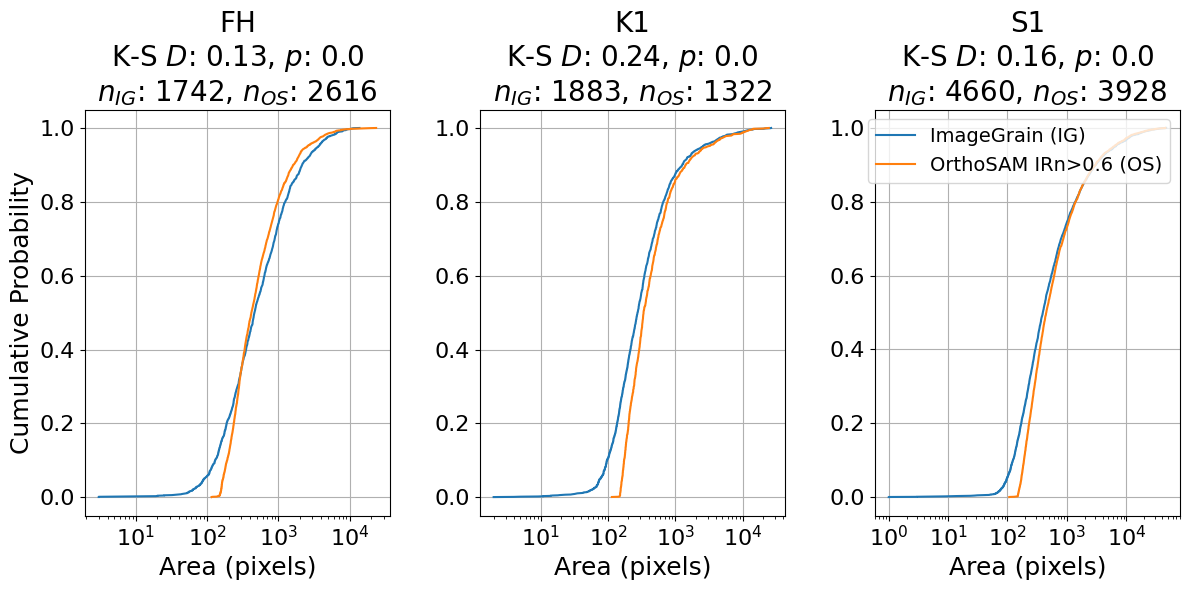

In [46]:
def cdf(title_label, mask, props_df):    
    sizes = np.sort(np.unique(mask, return_counts=True)[1][1:])
    cdf = np.arange(1, len(sizes) + 1) / len(sizes)
    plt.plot(sizes, cdf, linestyle="-", label='ImageGrain (IG)')
    plt.title(title_label, fontsize=20)
    
    sizes_re = np.sort(props_df[props_df['IRn']>0.7]['area'])
    cdf_re = np.arange(1, len(sizes_re) + 1) / len(sizes_re)
    plt.plot(sizes_re, cdf_re, linestyle="-", label='OrthoSAM IRn>0.6 (OS)')
    ks_test=ks_2samp(sizes_re,sizes, method= 'exact', alternative='two-sided')


    #precision = TP_count / MSK_T
    #recall = TP_count / Label_count
    plt.title(title_label+'\n'
              +fr'K-S $D$: {np.round(ks_test[0],2):.2}, $p$: {np.round(ks_test[1],2):.3}'
              #+'\n'+r', K-S$_{OSs}$'+ f'$D$: {np.round(ks_test2[0],2):.2}, $p$: {np.round(ks_test2[1],2):.3}'
              +'\n'+r'$n_{IG}$'
              +f': {len(sizes)}, '
              +r'$n_{OS}$'+f': {len(sizes_re)}'
              #+'\n'+r'$n_{OSs}$'+f': {len(sizes_re2)}'
              #+'\n'+f'P: {precision:.2}, R: {recall:.2}'
              , fontsize=20)

    plt.xscale("log")
    plt.xlabel("Area (pixels)", fontsize=18)
    plt.ylabel("Cumulative Probability", fontsize=18) 
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)       
    plt.grid(True)
plt.figure(figsize=(12, 6))
plt.subplot(1,3,1)
cdf('FH', mask_FH, props_df_FH)
plt.subplot(1,3,2)
cdf('K1', mask_K1, props_df_K1)
plt.ylabel('')
plt.subplot(1,3,3)
cdf('S1', mask_S1, props_df_S1)
plt.legend(fontsize=14)
plt.tight_layout()
plt.xlabel('Area (pixels)')
plt.ylabel('')

In [14]:
def precision_recall_return(AcDic):
    #threshold=0.9
    #iou = np.abs(np.array(AcDic.get('iou')))
    ac_class, count = np.unique(AcDic.get('point based'), return_counts=True)
    #TP_count = np.sum(iou >= threshold)
    TP_count = np.sum(count[ac_class > 0]) if 1 in ac_class else 0
    Label_count = AcDic.get('label_count')
    MSK_T = AcDic.get('mask_count')

    precision = TP_count / MSK_T
    recall = TP_count / Label_count
    return precision, recall
import pandas as pd
import dataframe_image as dfi
#precisions=[precision_recall_return(AcDic_FH)[0],precision_recall_return(AcDic_K1)[0],precision_recall_return(AcDic_S1)[0]]
#recalls=[precision_recall_return(AcDic_FH)[1],precision_recall_return(AcDic_K1)[1],precision_recall_return(AcDic_S1)[1]]
#mean_iou=[0.704, 0.754, 0.739]
#mean_iou=[0.661, 0.556, 0.600]
mask_count=[1742, 1883, 4660]
pred_count=[2819, 1358, 4316]
df=pd.DataFrame({'Image':['FH','K1','S1']
                 #,'Precision':precisions,'Recall':recalls
                 #, 'Mean IoU':mean_iou
                 , 'ImageGrain': mask_count
                 , 'OrthoSAM': pred_count
                 , 'OrthoSAM IRn>0.7': [len(props_df_FH['IRn']>0.7), len(props_df_K1['IRn']>0.7), len(props_df_S1['IRn']>0.7)]
                 , 'OrthSAM (standard settings)': [len(np.unique(pred2_FH))-1, len(np.unique(pred2_k1))-1, len(np.unique(pred2_S1))-1]
                 , 'OrthSAM (standard settings) IRn>0.7': [len(props_df_FH2['IRn']>0.7), len(props_df_K12['IRn']>0.7), len(props_df_S12['IRn']>0.7)]
                 })
pd.set_option('display.float_format', '{:.3f}'.format)

dfi.export(df, "new_imagegrain.jpg", table_conversion="matplotlib")


In [11]:
len(props_df_FH['IRn']>0.7)

2781

In [44]:
labeled_mask_S1 = label(pred_S1, background=0)
labeled_mask_S1=labeled_mask_S1.astype(float)
labeled_mask_S1[labeled_mask_S1==0]=np.nan
removed=labeled_mask_S1.copy()
labeled_mask_S1[~np.isin(labeled_mask_S1, list(np.array(props_df_S1[props_df_S1['IRn']>0.7]['label'])))] = 0

removed[~np.isin(removed, list(np.array(props_df_S1[props_df_S1['IRn']<0.6]['label'])))] =np.nan


Text(0.5, 1.0, 'IRn<0.6')

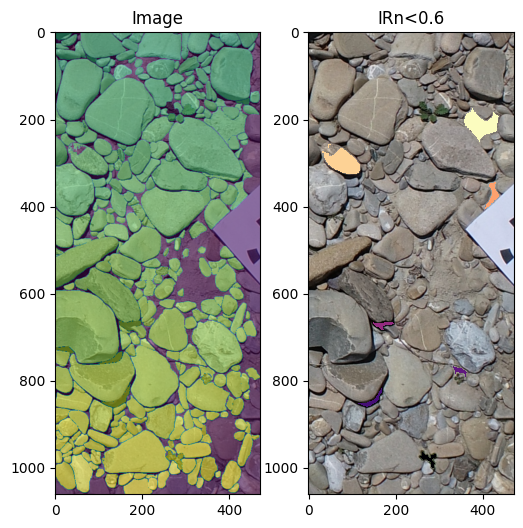

In [46]:
plt.figure(figsize=(6,6))
plt.subplot(1,2,1)
plt.imshow(img_S1[2000:, 2250:, :])
# pred_S1_p = pred_S1.copy().astype("float")
# pred_S1_p[pred_S1_p == 0] = np.nan
# pred_S1_p = graph_coloring(pred_S1_p)
plt.imshow(pred_S1[2000:,2250:], alpha=0.5)
plt.title('Image')
plt.subplot(1,2,2)
plt.imshow(img_S1[2000:, 2250:, :])
# pred_S1_p = labeled_mask_S1.copy().astype("float")
# pred_S1_p[pred_S1_p == 0] = np.nan
# pred_S1_p = graph_coloring(pred_S1_p)
# plt.imshow(pred_S1_p[-250:,-250:], alpha=0.5)
#plt.imshow(labeled_mask_S1[-250:, -250:])
plt.imshow(removed[2000:,2250:], cmap='magma_r')
plt.title('IRn<0.6')

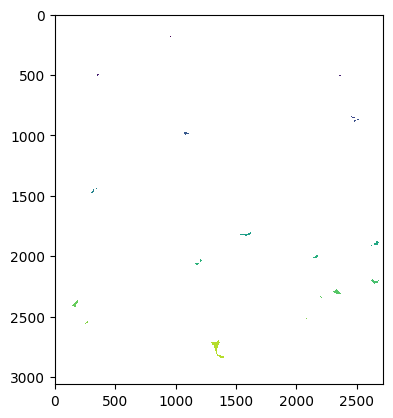

In [39]:
plt.imshow(removed)

In [ ]:
or_im_recll=[0.870, 0.888, 0.909]
im_or_recall=[0.358,0.75,0.664]
mean_iou=[0.704, 0.754, 0.739]
df=pd.DataFrame({'Image':['FH','K1','S1']
                 ,'ImageGrain based Recall':or_im_recll,'OrthoSAM based Recall':im_or_recall
                 , 'Mean IoU':mean_iou
                 , 'OrthoSAM Prediction': pred_count, 'ImageGrain prediction': mask_count})
pd.set_option('display.float_format', '{:.3f}'.format)
dfi.export(df, "recalls.jpg", table_conversion="matplotlib")